<a href="https://colab.research.google.com/github/amoghvd/ML-lab-2547211/blob/LAB-6/LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Experiment: Linear Regression through Gradient Descent
## 1. Dataset Loading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))

inner_zip_data = z.read('student.zip')
with zipfile.ZipFile(io.BytesIO(inner_zip_data)) as z2:
    df = pd.read_csv(z2.open('student-mat.csv'), sep=';')

display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


This step involves importing the necessary libraries for data handling and numerical operations. We use the requests and zipfile modules to download and extract the dataset directly from the UCI repository. The data is loaded into a pandas DataFrame using a semicolon separator as specified by the dataset documentation.

## 2. Preprocessing

In [9]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['G3']).values
y = df['G3'].values.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In this phase we prepare the data for the model. First we convert text based categories into numbers so the computer can process them. Then we separate our features from the target grade variable. We apply scaling to ensure all features have a similar range which helps the optimization algorithm work faster. Finally we split the data into a training group and a testing group.

## 3. Gradient Descent Implementation

In [10]:
def gradient_descent(X, y, lr, iterations):
    m, n = X.shape
    theta = np.zeros((n, 1))
    bias = 0
    loss_history = []
    for _ in range(iterations):
        prediction = np.dot(X, theta) + bias
        error = prediction - y
        loss = (1 / (2 * m)) * np.sum(error**2)
        loss_history.append(loss)
        d_theta = (1 / m) * np.dot(X.T, error)
        d_bias = (1 / m) * np.sum(error)
        theta -= lr * d_theta
        bias -= lr * d_bias
    return theta, bias, loss_history

lr = 0.01
iterations = 1000
theta, bias, losses = gradient_descent(X_train, y_train, lr, iterations)

This part contains the core math for the experiment. We initialize our starting weights at zero. During every iteration the code calculates a prediction and determines how far off it is from the actual result. It then calculates the slope or gradient to see which direction to move the weights to reduce the error. We update the weights by taking a small step determined by the learning rate.

## 4. Evaluation

MAE: 1.5465442517695527
MSE: 5.09290834757595
RMSE: 2.2567472936897364
R2 Score: 0.7516265980275255


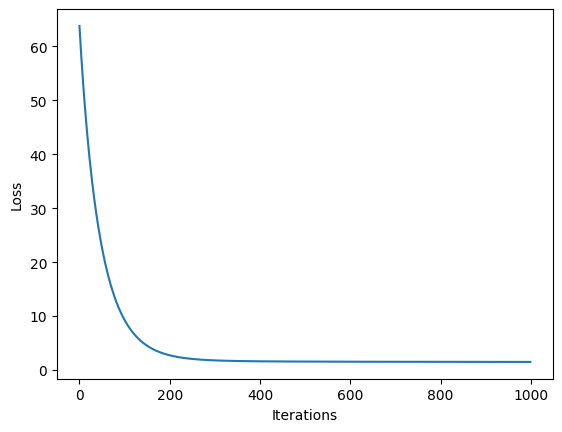

In [11]:
y_pred = np.dot(X_test, theta) + bias
mse = np.mean((y_test - y_pred)**2)
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(mse)
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

plt.plot(range(iterations), losses)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

This final section measures how well the model learned. We use the test data to see if the model can predict grades it has not seen before. Metrics like mean absolute error tell us the average mistake size while the R2 score tells us how much of the variation in grades we successfully captured. The plot shows the loss decreasing over time which proves that the gradient descent algorithm is successfully finding better weights.